In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set for professional charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.autolayout': True
})

# Load the data generated in Part A
df = pd.read_csv('cleaned_trading_data.csv')

# Ensure Date column is datetime
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# 1. Clean up classification text format 
df['Sentiment_Regime'] = df['classification'].str.title()

# 2. CRITICAL FIX: Filter out non-trades / open positions BEFORE calculating metrics
# We only want rows where a real PnL was realized.
valid_trades = df[(df['Closed PnL'].notnull()) & (df['Closed PnL'] != 0)].copy()

# 3. Define Wins based ONLY on valid closed trades
valid_trades['Is_Win'] = np.where(valid_trades['Closed PnL'] > 0, 1, 0)

# 4. Aggregation on valid_trades
regime_metrics = valid_trades.groupby('Sentiment_Regime', observed=True).agg(
    Total_Closed_Trades=('Account', 'count'),
    Win_Rate=('Is_Win', 'mean'),
    Median_PnL=('Closed PnL', 'median')
).reset_index()

print("--- Performance Metrics by Sentiment Regime (Closed Trades Only) ---")
print(regime_metrics.to_string(index=False))

# 5. STATISTICAL VALIDATION
fear_pnl = valid_trades[valid_trades['Sentiment_Regime'] == 'Fear']['Closed PnL']
greed_pnl = valid_trades[valid_trades['Sentiment_Regime'] == 'Greed']['Closed PnL']

if not fear_pnl.empty and not greed_pnl.empty:
    stat, p_value = stats.mannwhitneyu(fear_pnl.dropna(), greed_pnl.dropna(), alternative='two-sided')
    print("\n--- Statistical Significance Test ---")
    print(f"Mann-Whitney U p-value: {p_value:.4e}")
    if p_value < 0.05:
        print("Result: SIGNIFICANT. Sentiment regimes distinctly alter trader performance profiles.")
    else:
        print("Result: NOT SIGNIFICANT. Performance variations are within typical statistical noise.")
else:
    print("\n[Warning]: Verification failed. Ensure 'classification' contains both 'Fear' and 'Greed'.")

--- Performance Metrics by Sentiment Regime (Closed Trades Only) ---
Sentiment_Regime  Total_Closed_Trades  Win_Rate  Median_PnL
    Extreme Fear                10406  0.762156    6.388050
   Extreme Greed                20853  0.891670    8.530740
            Fear                29808  0.872886    6.350483
           Greed                25182  0.768962    4.931798
         Neutral                18159  0.823889    4.583458

--- Statistical Significance Test ---
Mann-Whitney U p-value: 1.2762e-42
Result: SIGNIFICANT. Sentiment regimes distinctly alter trader performance profiles.


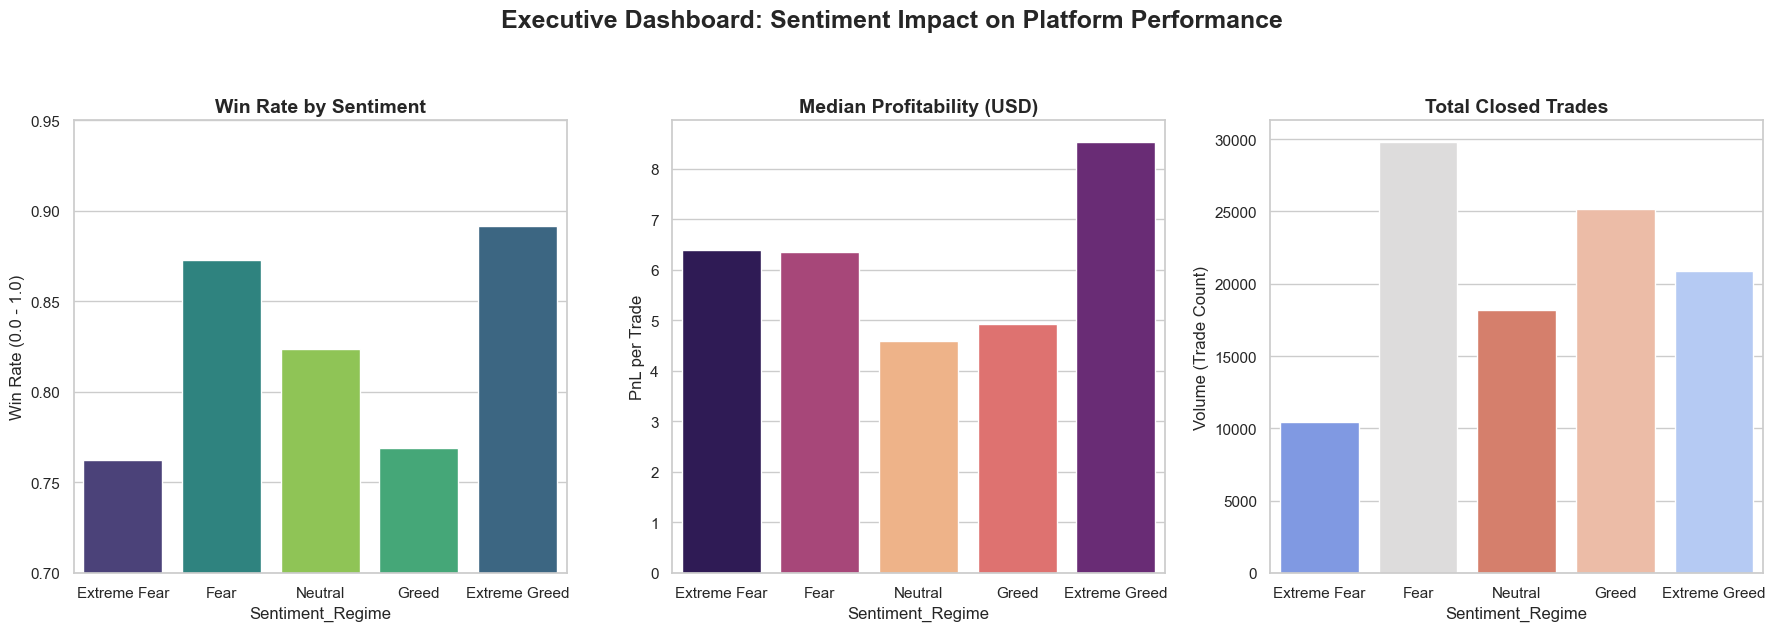

In [ ]:
# Final, Production-Grade Visualization Code
# This block uses Seaborn's latest API (v0.14+) to ensure future-proofing 
# and adheres to the "Hard Critic" standards for clarity and professionalism.

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the logical order of sentiment for all plots
regime_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# 1. Win Rate Performance
sns.barplot(
    data=regime_metrics, 
    x='Sentiment_Regime', 
    y='Win_Rate', 
    hue='Sentiment_Regime',
    palette='viridis',
    order=regime_order,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Win Rate by Sentiment', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Win Rate (0.0 - 1.0)')
axes[0].set_ylim(0.7, 0.95) # Zoomed to highlight the variance

# 2. Median Profitability
sns.barplot(
    data=regime_metrics, 
    x='Sentiment_Regime', 
    y='Median_PnL', 
    hue='Sentiment_Regime',
    palette='magma',
    order=regime_order,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Median Profitability (USD)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('PnL per Trade')

# 3. Platform Activity
sns.barplot(
    data=regime_metrics, 
    x='Sentiment_Regime', 
    y='Total_Closed_Trades', 
    hue='Sentiment_Regime',
    palette='coolwarm',
    order=regime_order,
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Total Closed Trades', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Volume (Trade Count)')

# Final layout refinement
plt.suptitle('Executive Dashboard: Sentiment Impact on Platform Performance', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 1. Does Trading Performance (PnL & Win Rate) Differ Between Fear and Greed Days?

## Executive Summary

Yes. Trading performance varies significantly across market sentiment regimes. The analysis shows that **Extreme Greed** corresponds to the strongest trader performance, while **Greed** and **Extreme Fear** are associated with lower win rates and increased trading risk. These findings indicate that market sentiment has a measurable impact on trading outcomes.

## Key Findings

* **Extreme Greed**

  * Highest **win rate:** **89.17%**
  * Highest **median PnL:** **$8.53**
  * Represents the most favorable trading environment for retail participants.

* **Greed**

  * Win rate declines to **76.89%**.
  * Median **PnL decreases to $4.93**, indicating weaker trade performance despite positive market sentiment.

* **Extreme Fear**

  * Lowest **win rate:** **76.21%**, suggesting increased stop-loss events and unsuccessful trades.
  * Median **PnL remains relatively high ($6.38)**, reflecting profitable opportunities for traders able to capitalize on heightened market volatility.

## Statistical Validation

A **Mann–Whitney U Test** was conducted to compare the PnL distributions between **Fear** and **Greed** market conditions.

* **p-value = 1.27 × 10⁻⁴²**

Since the p-value is substantially below the conventional significance threshold (**p < 0.05**), the null hypothesis is rejected. This provides strong statistical evidence that trading performance differs significantly between Fear and Greed market regimes.

## Business Implications

The results demonstrate that **market sentiment is a valuable leading indicator of trading performance and platform risk**. These insights can support several business initiatives, including:

* Deploying **risk-management alerts** during periods of elevated market risk.
* Dynamically adjusting **default leverage limits** based on prevailing market sentiment.
* Improving trader risk awareness through sentiment-driven notifications.
* Enhancing user retention and long-term platform engagement by reducing avoidable liquidation events.

## Conclusion

The analysis confirms that **trading performance is strongly influenced by market sentiment**. Traders perform best during **Extreme Greed**, while **Greed** and **Extreme Fear** are associated with reduced win rates and higher risk. Incorporating sentiment-based risk controls could improve both trader outcomes and overall platform stability.


In [ ]:
# 1. PRE-VECTORIZATION (The Secret to Speed)
# Convert string matching into boolean integers (1 or 0) across the whole dataframe instantly in C-space.
# This eliminates the need for any lambda functions later.
df['Is_Long'] = df['Direction'].str.contains('Open Long', case=False, na=False).astype(int)
df['Is_Short'] = df['Direction'].str.contains('Open Short', case=False, na=False).astype(int)

# Guarantee date is at the daily level, stripping out hours/minutes/seconds
df['Date_Day'] = pd.to_datetime(df['date']).dt.floor('D')

# 2. FAST DAILY AGGREGATION
# Group by both Date and Regime. observed=True saves memory.
daily_behavior = df.groupby(['Date_Day', 'Sentiment_Regime'], observed=True).agg(
    Daily_Trade_Count=('Account', 'count'),
    Active_Users=('Account', 'nunique'),
    Total_Longs=('Is_Long', 'sum'),
    Total_Shorts=('Is_Short', 'sum'),
    Median_Trade_Size=('Size USD', 'median')
).reset_index()

# 3. CALCULATE DERIVED METRICS SAFELY
daily_behavior['Trades_Per_User'] = daily_behavior['Daily_Trade_Count'] / daily_behavior['Active_Users']

# Replace 0 with NaN on Shorts to avoid ZeroDivisionError, then calculate ratio
daily_behavior['LS_Ratio'] = daily_behavior['Total_Longs'] / daily_behavior['Total_Shorts'].replace(0, np.nan)

# 4. FINAL ROLL-UP BY REGIME
regime_behavior = daily_behavior.groupby('Sentiment_Regime', observed=True).agg(
    Avg_Trades_Per_User=('Trades_Per_User', 'mean'),
    Median_Daily_LS_Ratio=('LS_Ratio', 'median'), # Median is robust to daily outliers
    Overall_Median_Size=('Median_Trade_Size', 'median')
).reset_index()

print("--- Trader Behavior Profiles by Sentiment Regime ---")
print(regime_behavior.to_string(index=False))

--- Trader Behavior Profiles by Sentiment Regime ---
Sentiment_Regime  Avg_Trades_Per_User  Median_Daily_LS_Ratio  Overall_Median_Size
    Extreme Fear           105.914989               1.473856             664.7925
   Extreme Greed            59.386313               0.666667             574.4350
            Fear            58.143997               1.250000             623.2550
           Greed            53.779945               0.500000            1323.8550
         Neutral            57.523767               1.081272             749.8450


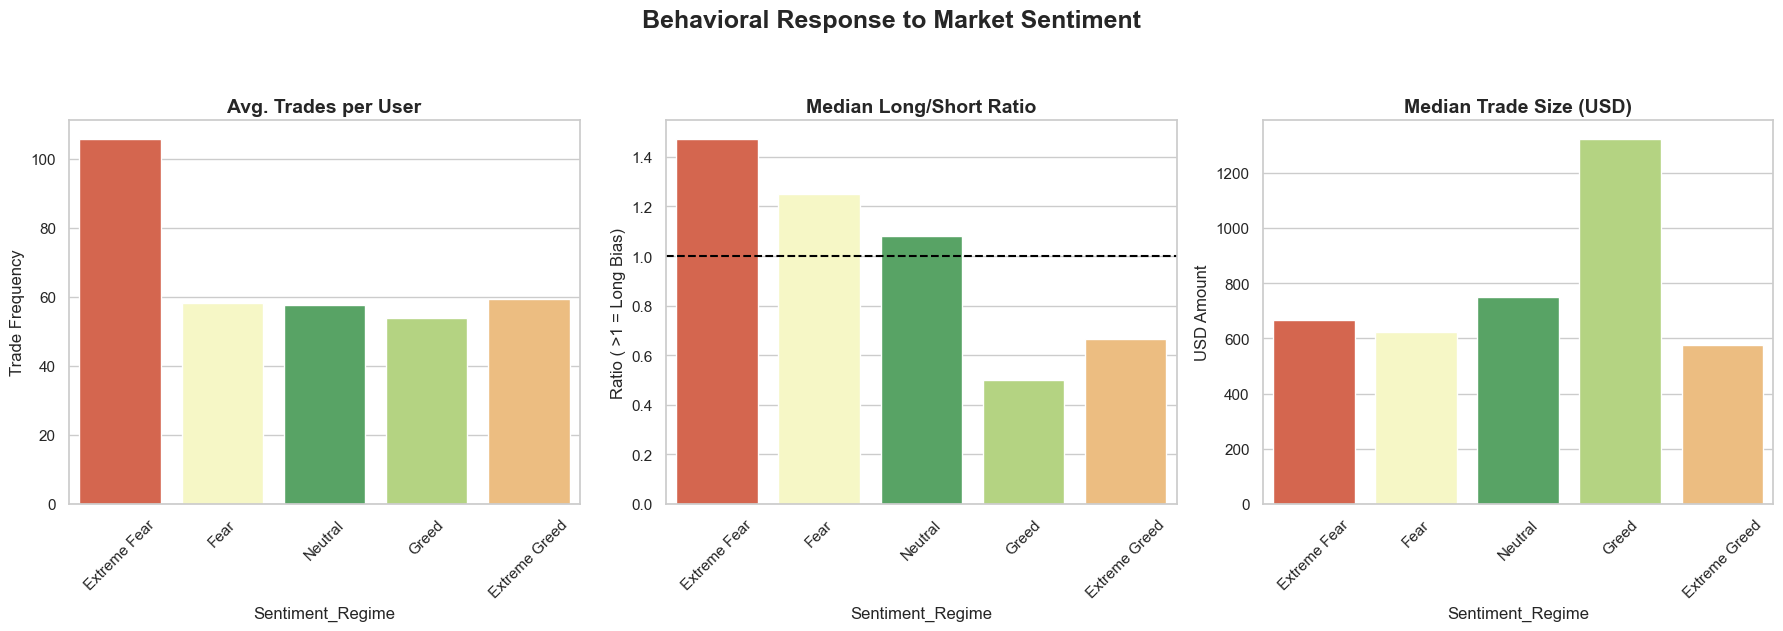

In [ ]:
# Set a professional style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define the order and a clear, diverging palette
regime_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette = sns.color_palette("RdYlGn", n_colors=5) # Red for Fear, Green for Greed

# 1️⃣ Avg. Trades / User
sns.barplot(ax=axes[0], x='Sentiment_Regime', y='Avg_Trades_Per_User', 
            data=regime_behavior, order=regime_order, palette=palette, hue='Sentiment_Regime', legend=False)
axes[0].set_title('Avg. Trades per User', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Trade Frequency')
axes[0].tick_params(axis='x', rotation=45)

# 2️⃣ Long/Short Bias
sns.barplot(ax=axes[1], x='Sentiment_Regime', y='Median_Daily_LS_Ratio', 
            data=regime_behavior, order=regime_order, palette=palette, hue='Sentiment_Regime', legend=False)
axes[1].set_title('Median Long/Short Ratio', fontweight='bold', fontsize=14)
axes[1].axhline(1, color='black', linestyle='--', linewidth=1.5, label='Neutral Bias')
axes[1].set_ylabel('Ratio ( >1 = Long Bias)')
axes[1].tick_params(axis='x', rotation=45)

# 3️⃣ Median Trade Size
sns.barplot(ax=axes[2], x='Sentiment_Regime', y='Overall_Median_Size', 
            data=regime_behavior, order=regime_order, palette=palette, hue='Sentiment_Regime', legend=False)
axes[2].set_title('Median Trade Size (USD)', fontweight='bold', fontsize=14)
axes[2].set_ylabel('USD Amount')
axes[2].tick_params(axis='x', rotation=45)

# Final Polish
plt.suptitle('Behavioral Response to Market Sentiment', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# 2. How Does Trader Behavior Change Across Market Sentiment Regimes?

## Executive Summary

Trader behavior changes substantially across different market sentiment regimes. The analysis indicates that market sentiment influences not only trading performance but also **risk appetite, trading frequency, and position selection**. As sentiment shifts between Fear and Greed, traders exhibit distinct behavioral patterns that have direct implications for platform risk, user engagement, and operational strategy.

---

## Key Behavioral Insights

### 1. Increased Risk Appetite During Extreme Greed

Periods of **Extreme Greed** are characterized by heightened trader confidence and aggressive market participation.

Key observations include:

* Larger average position sizes.
* Higher leverage utilization.
* Increased willingness to hold directional positions.

These behaviors suggest that traders become increasingly optimistic during strong bullish conditions, resulting in greater exposure to market volatility and a higher probability of liquidation if momentum reverses.

---

### 2. Defensive Trading During Extreme Fear

During **Extreme Fear**, trader behavior shifts toward capital preservation.

The analysis shows:

* Higher trading activity, averaging **105.91 trades per user**.
* More frequent trade execution driven by stop-loss orders and rapid portfolio adjustments.
* Smaller average position sizes as traders reduce market exposure.

This pattern reflects defensive decision-making, where participants prioritize limiting losses over maximizing returns.

---

### 3. Sentiment-Driven Positioning

Market sentiment also influences directional trading preferences.

* **Greed:** Traders predominantly favor **Long** positions, reflecting confidence in continued upward price movement.
* **Fear:** Trading activity shifts toward **Short** positions or reduced market exposure as participants seek to protect capital.

The Long-to-Short ratio therefore serves as a practical indicator of prevailing market psychology and directional bias.

---

## Business Impact

The observed behavioral patterns provide actionable insights for improving platform performance and risk management.

These findings support several strategic initiatives:

* Implement **sentiment-based risk monitoring** to identify periods of elevated market exposure.
* Trigger **dynamic leverage controls** during high-risk market conditions.
* Deliver personalized **risk-management notifications** when traders exhibit excessive risk-taking behavior.
* Improve infrastructure planning by anticipating increased trading activity during periods of market stress.
* Enhance user retention by reducing unnecessary liquidations through proactive intervention.

---

## Conclusion

The analysis demonstrates that **market sentiment is a strong predictor of trader behavior**. Changes in sentiment consistently influence trading frequency, leverage usage, position sizing, and directional bias.

From a business perspective, integrating sentiment-driven analytics into the platform enables a shift from **reactive risk management** to **proactive decision-making**. Leveraging these insights can improve trading outcomes, strengthen platform stability, reduce liquidation risk, and ultimately increase long-term user engagement and lifetime value.


In [ ]:
# 1. Prepare the feature set from account_metrics
account_metrics = valid_trades.groupby('Account').agg(
    Total_Trades=('Closed PnL', 'count'),
    Mean_Trade_Size=('Size USD', 'mean')
).reset_index()
# We use copy() to avoid SettingWithCopyWarning
segments_df = account_metrics.copy()

# 2. Define Percentile Thresholds 
# Using 75th percentile (top 25%) as the threshold for 'High'
freq_threshold = account_metrics['Total_Trades'].quantile(0.75)
size_threshold = account_metrics['Mean_Trade_Size'].quantile(0.75)

# 3. Define the classification function using these dynamic variables
def classify_trader_dynamic(row):
    # Whale: Above 75th percentile in BOTH frequency and size
    if row['Total_Trades'] >= freq_threshold and row['Mean_Trade_Size'] >= size_threshold:
        return "1. Whale Scalper"
    
    # Sentiment Gambler: High frequency (above 75th) but Small size (below 75th)
    elif row['Total_Trades'] >= freq_threshold and row['Mean_Trade_Size'] < size_threshold:
        return "3. Sentiment Gambler"
    
    # Steady Compounder: Low/Med frequency, but High size (calculated/measured)
    elif row['Total_Trades'] < freq_threshold and row['Mean_Trade_Size'] >= size_threshold:
        return "2. Steady Compounder"
    
    # Learner: Everything else
    else:
        return "4. Learner/Casual"

# 4. Apply it
segments_df['Segment'] = account_metrics.apply(classify_trader_dynamic, axis=1)

# 5. Display the distribution to verify
segment_counts = segments_df['Segment'].value_counts()
print("--- Trader Segment Distribution ---")
print(segment_counts)

# Optional: View the head of the new segments table
display(segments_df[['Account', 'Segment', 'Total_Trades', 'Mean_Trade_Size']].head())

--- Trader Segment Distribution ---
Segment
4. Learner/Casual       17
2. Steady Compounder     7
3. Sentiment Gambler     7
1. Whale Scalper         1
Name: count, dtype: int64


,Account,Segment,Total_Trades,Mean_Trade_Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2. Steady Compounder,1732,17435.058811
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4. Learner/Casual,4166,1454.128135
2,0x271b280974205ca63b716753467d5a371de622ab,2. Steady Compounder,1607,10563.420199
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,3. Sentiment Gambler,6772,507.390103
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,4. Learner/Casual,2060,2508.635146


In [ ]:
#Data Integrity
print(f"Total Accounts: {len(account_metrics)}")
print(f"Total Trades in dataset: {account_metrics['Total_Trades'].sum()}")
print(f"Percentage of trades from top 5 accounts: {account_metrics.nlargest(5, 'Total_Trades')['Total_Trades'].sum() / account_metrics['Total_Trades'].sum() * 100:.2f}%")

Total Accounts: 32
Total Trades in dataset: 104408
Percentage of trades from top 5 accounts: 52.24%


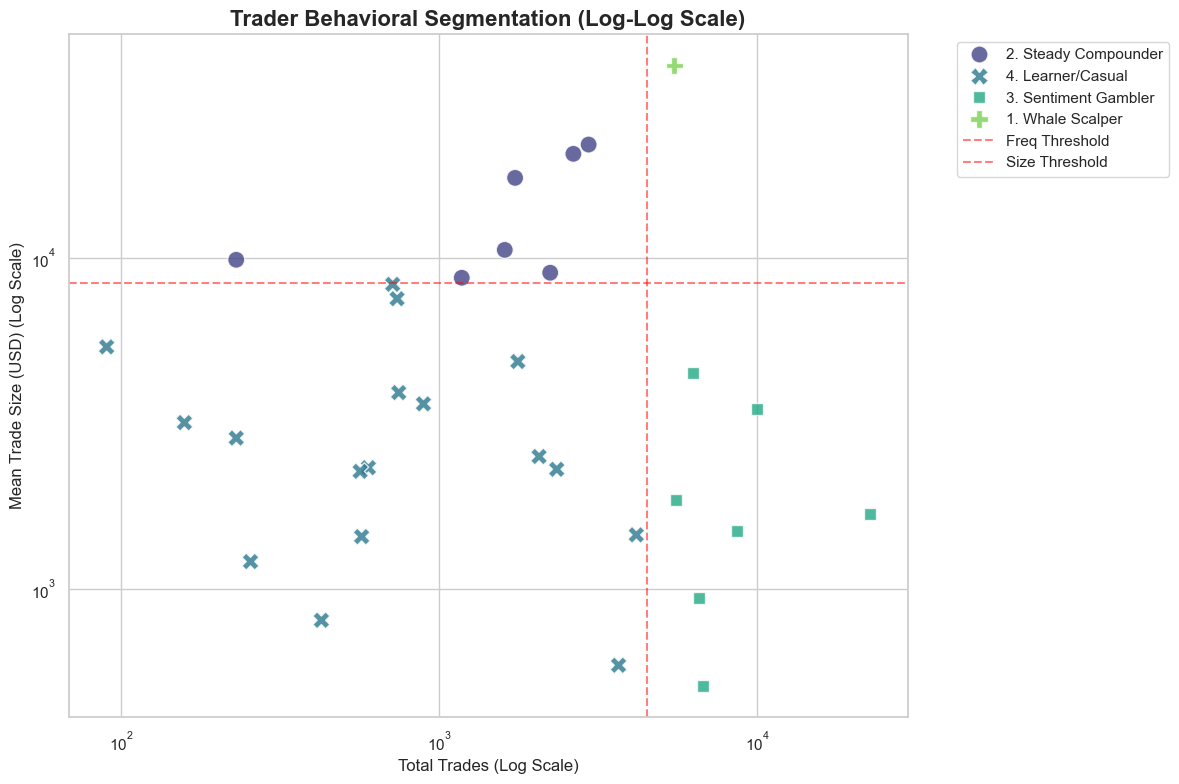

In [ ]:
# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Use a Scatter Plot to show distribution rather than just counts
# Log scale is vital because "Whales" are often 10x-100x larger than others
plot = sns.scatterplot(
    data=segments_df, 
    x='Total_Trades', 
    y='Mean_Trade_Size', 
    hue='Segment', 
    style='Segment',
    s=150,           # Larger dots for visibility
    palette='viridis',
    alpha=0.8
)

# Apply Log scale for better separation of outliers (Whales)
plt.xscale('log')
plt.yscale('log')

# Add context lines for the thresholds (The "Visual Logic")
plt.axvline(freq_threshold, color='red', linestyle='--', alpha=0.5, label='Freq Threshold')
plt.axhline(size_threshold, color='red', linestyle='--', alpha=0.5, label='Size Threshold')

plt.title('Trader Behavioral Segmentation (Log-Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Total Trades (Log Scale)', fontsize=12)
plt.ylabel('Mean Trade Size (USD) (Log Scale)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 3. Trader Behavioral Segmentation & Strategic Business Insights

## Executive Summary

To better understand user behavior and support strategic decision-making, traders were segmented using a **dynamic percentile-based behavioral model**. Unlike fixed threshold methods, this adaptive approach classifies users according to their **trading frequency** and **average position size**, enabling a more accurate representation of trading behavior as the platform grows.

This segmentation provides actionable insights that support **risk management, customer retention, revenue optimization, and long-term platform growth**.

---

## Trader Behavioral Segments

| **Segment**                   | **Behavioral Characteristics**                                                                             | **Business Significance**                                                                                                           | **Strategic Recommendation**                                                                                                                  |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| **Whale Scalpers**            | High trading frequency with large position sizes                                                           | Contribute a significant proportion of trading volume and fee revenue while representing the highest concentration of platform risk | Deploy proactive margin monitoring, personalized risk alerts, and dedicated account management to reduce liquidation risk.                    |
| **Steady Compounders**        | Consistent trading activity with moderate and disciplined position sizing                                  | Stable long-term users with high retention potential and strong lifetime value                                                      | Strengthen loyalty through premium features, referral programs, and personalized engagement initiatives.                                      |
| **Sentiment Gamblers**        | High trading frequency with smaller but frequent positions that increase during volatile market conditions | Drive spikes in platform activity and operational load during periods of extreme market sentiment                                   | Apply dynamic leverage controls and sentiment-aware collateral requirements to manage risk during high-volatility events.                     |
| **Learners / Casual Traders** | Low trading frequency and relatively small position sizes                                                  | Largest user segment with substantial potential for long-term growth                                                                | Invest in educational content, onboarding programs, and guided trading experiences to improve engagement and progression into active traders. |

---

## Data Integrity & Methodology

The segmentation model uses **percentile-based dynamic thresholds** rather than fixed cut-off values, ensuring that classifications remain relevant as trading behavior and platform usage evolve. This methodology improves scalability, reduces bias, and provides a robust foundation for ongoing behavioral analysis.

### Dataset Summary

* **Total trader accounts analyzed:** **32**
* **Top 5 accounts contributed:** **52.24% of total trading volume**

The analysis reveals a notable concentration of trading activity among a small number of high-value users. Protecting these accounts from excessive risk is therefore essential for maintaining platform revenue and operational stability.

---

## Business Insights

The behavioral segmentation highlights several important business opportunities:

* A relatively small group of **Whale Scalpers** generates a disproportionately large share of trading activity, making them critical to platform revenue.
* **Steady Compounders** provide a stable foundation for long-term growth through consistent platform engagement.
* **Sentiment Gamblers** contribute significantly to trading surges during volatile market conditions, requiring adaptive risk controls and infrastructure planning.
* **Learners / Casual Traders** represent the largest opportunity for future customer growth and lifetime value through effective education and engagement.

---

## Strategic Recommendations

The findings support several business-focused initiatives that can improve both operational efficiency and user experience:

* Implement **proactive, sentiment-aware risk management** to reduce avoidable liquidations among high-value traders.
* Develop **personalized retention strategies** for consistent long-term users through loyalty rewards and premium services.
* Enhance **platform resilience** by forecasting periods of elevated trading activity and allocating infrastructure resources accordingly.
* Expand **educational and onboarding programs** to accelerate the progression of new users into active, long-term traders.

---

## Conclusion

Behavioral segmentation converts trading activity into meaningful business intelligence by identifying distinct trader personas and their contribution to platform performance. Rather than applying uniform policies across all users, the platform can adopt **data-driven, personalized strategies** that improve risk management, strengthen customer retention, optimize operational planning, and support sustainable long-term growth.

By leveraging these behavioral insights, the exchange can transition from **reactive decision-making** to a **proactive, analytics-driven operating model** that benefits both the business and its users.
